In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
df = pd.read_csv("sales_data.csv")

In [3]:
df.head(10)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
5,2022-01-01,S001,P0006,Toys,North,209,60,0,35.53,0,Snowy,0,40.01,Winter,0,55
6,2022-01-01,S001,P0007,Groceries,North,118,81,335,23.27,5,Snowy,0,24.78,Winter,0,94
7,2022-01-01,S001,P0008,Electronics,North,244,42,0,37.79,5,Snowy,0,44.85,Winter,0,61
8,2022-01-01,S001,P0009,Clothing,North,115,88,139,94.20,5,Snowy,0,108.70,Winter,0,129
9,2022-01-01,S001,P0010,Furniture,North,192,70,300,113.35,10,Snowy,0,129.98,Winter,0,69


In [4]:
df.shape

(76000, 16)

In [5]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

In [7]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


In [8]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
print(df.columns)

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')


In [11]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Promotion', 'Competitor Pricing', 'Epidemic', 'Demand'],
      dtype='object')
Categorical Columns: Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Weather Condition', 'Seasonality'],
      dtype='object')


In [12]:
for col in cat_cols:
    print(col, df[col].nunique())

Date 760
Store ID 5
Product ID 20
Category 5
Region 4
Weather Condition 4
Seasonality 4


In [13]:
top_products = df.groupby("Category")["Demand"].sum().sort_values(ascending=False).head(5)
print(top_products)

Category
Groceries      3677684
Clothing       1369456
Furniture      1006590
Toys            985338
Electronics     889036
Name: Demand, dtype: int64


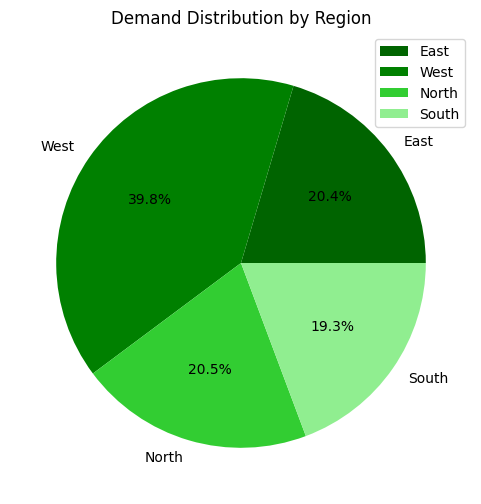

In [14]:
plt.figure(figsize=(6,6))

region_demand = df.groupby("Region")["Demand"].sum()

colors = ["darkgreen", "green", "limegreen", "lightgreen"]

plt.pie(region_demand,
        labels=["East","West","North","South"],
        autopct='%1.1f%%',
        colors=colors)

plt.title("Demand Distribution by Region")
plt.legend()

plt.show()

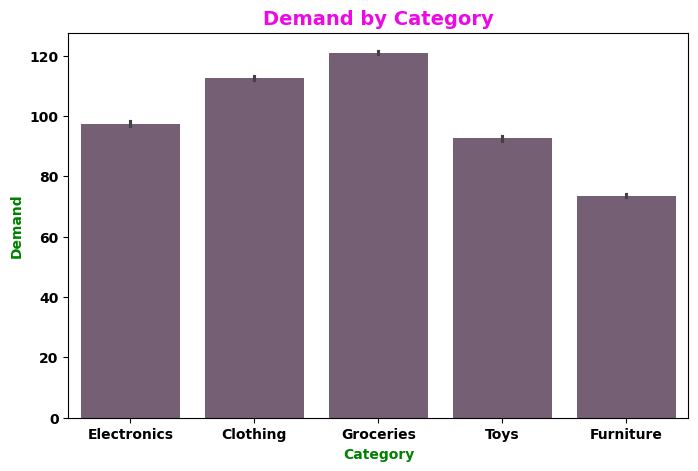

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(x="Category", y="Demand", data=df, color="#795B78")

plt.title("Demand by Category", color="#ED09E6", fontsize=14, fontweight="bold")

plt.xlabel("Category", color="green", fontweight="bold")


plt.ylabel("Demand", color="green", fontweight="bold")


plt.xticks( fontweight="bold")


plt.yticks(fontweight="bold")



plt.show()

In [16]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df.drop("Date", axis=1, inplace=True)

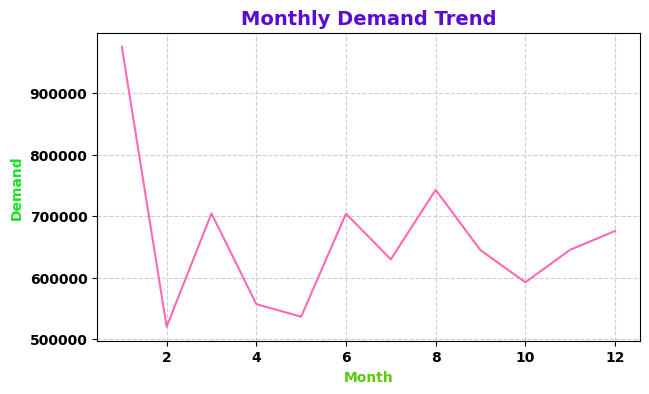

In [17]:
monthly_demand = df.groupby("Month")["Demand"].sum()

plt.figure(figsize=(7,4))

monthly_demand.plot(color="#FF69B4", linewidth=1.5)

plt.title("Monthly Demand Trend", color="#5A0CCF", fontsize=14, fontweight="bold")
plt.xlabel("Month", color="#57CB0A", fontweight="bold")
plt.ylabel("Demand", color="#14E322", fontweight="bold")


plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.grid(True, linestyle="--", alpha=0.6)



plt.show()

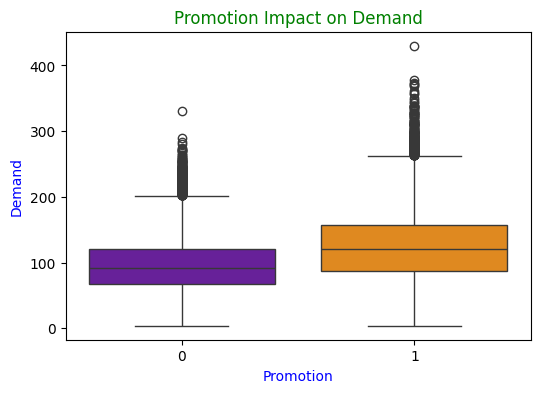

In [18]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Promotion",
    y="Demand",
    data=df,
    hue="Promotion",            
    palette=["#6a0dad", "#ff8c00"], 
    legend=False
)

plt.title("Promotion Impact on Demand", color="green")

plt.xlabel("Promotion", color="blue")
plt.ylabel("Demand", color="blue")

plt.show()

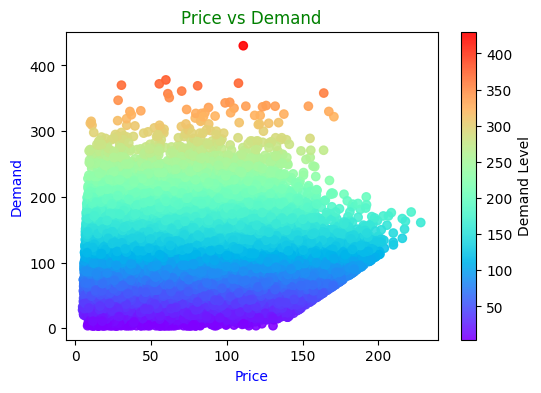

In [19]:
plt.figure(figsize=(6,4))

plt.scatter(
    df["Price"],
    df["Demand"],
    c=df["Demand"],      
    cmap="rainbow",      
    alpha=0.9
)

plt.title("Price vs Demand", color="green")

plt.xlabel("Price", color="blue")
plt.ylabel("Demand", color="blue")

plt.colorbar(label="Demand Level")

plt.show()

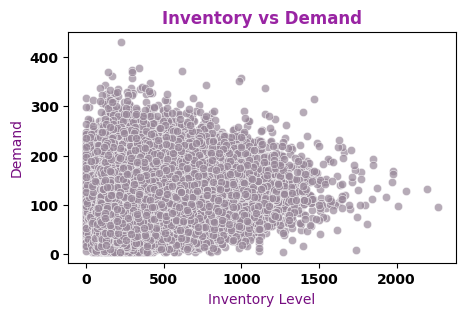

In [20]:
plt.figure(figsize=(5,3))

sns.scatterplot(
    x="Inventory Level",
    y="Demand",
    data=df,
    color="#988899",
    alpha=0.7
)

plt.title("Inventory vs Demand", color="#9924A3", fontweight="bold")

plt.xlabel("Inventory Level", color="#760D80")
plt.ylabel("Demand", color="#760D80")

plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.show()

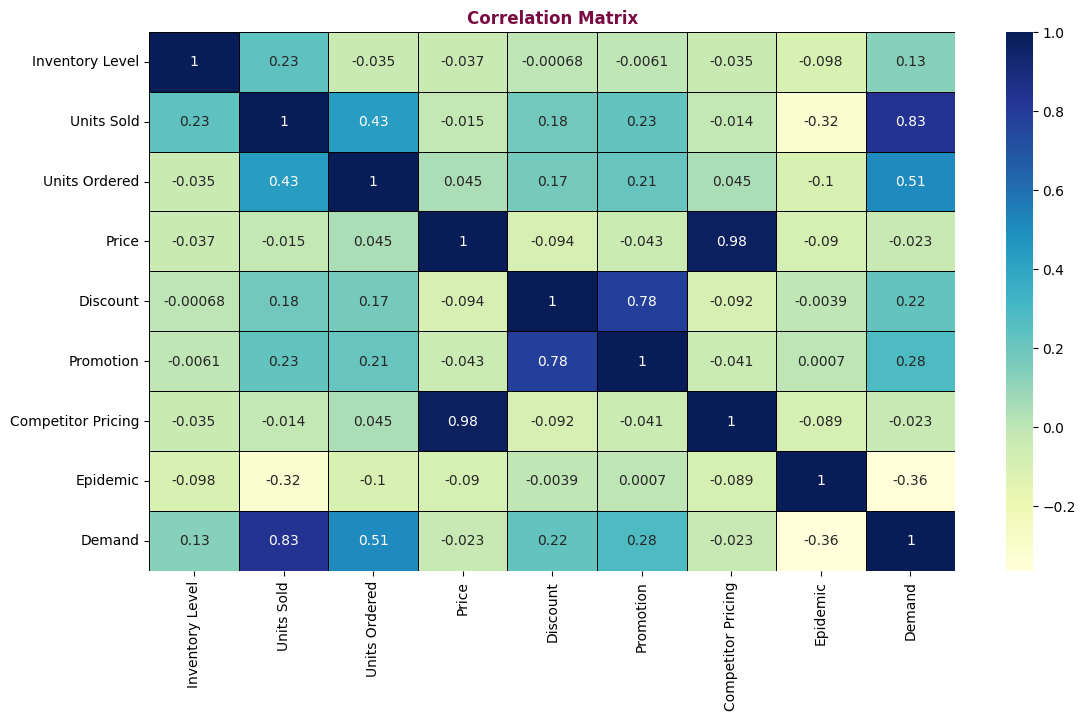

In [21]:
plt.figure(figsize=(13,7))
sns.heatmap(df.select_dtypes(include=["int64","float64"]).corr(), 
            annot=True, cmap="YlGnBu",       
    linewidths=0.5,       
    linecolor="black")
plt.title("Correlation Matrix", color="#790B42", fontweight="bold")
plt.show()

In [22]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df["Store ID"] = le.fit_transform(df["Store ID"])
df["Product ID"] = le.fit_transform(df["Product ID"])
df["Category"] = le.fit_transform(df["Category"])
df["Region"] = le.fit_transform(df["Region"])
df["Weather Condition"] = le.fit_transform(df["Weather Condition"])
df["Seasonality"] = le.fit_transform(df["Seasonality"])

In [23]:
X = df.drop(["Demand", "Units Sold"], axis=1)
y = df["Demand"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 27.90840506697835
MSE: 1265.8648419716994
R2 Score: 0.42682553239968835


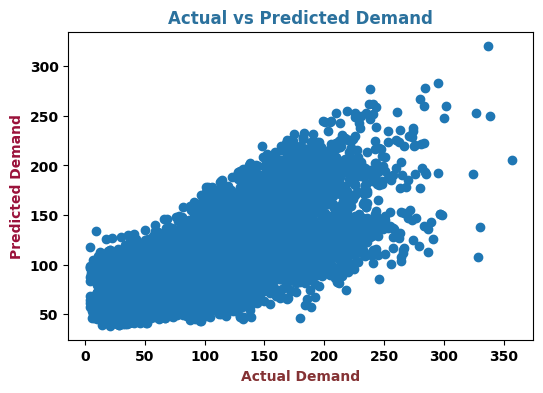

In [24]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Demand",color="#843234", fontweight="bold")
plt.ylabel("Predicted Demand",color="#9A113A", fontweight="bold")
plt.title("Actual vs Predicted Demand", color="#2B719D", fontweight="bold")
plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")
plt.show()

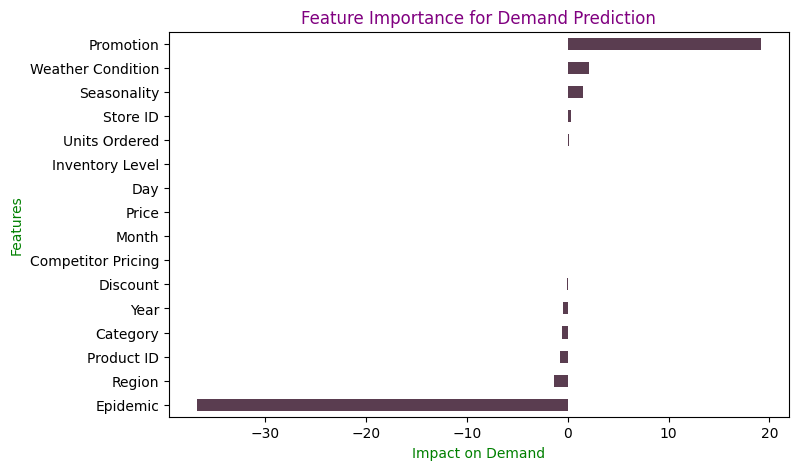

In [34]:
importance = pd.Series(model.coef_, index=X.columns)

plt.figure(figsize=(8,5))
importance.sort_values().plot(kind="barh",color="#5A3D50")
plt.title("Feature Importance for Demand Prediction", color="purple")
plt.xlabel("Impact on Demand", color="green")
plt.ylabel("Features", color="green")
plt.show()

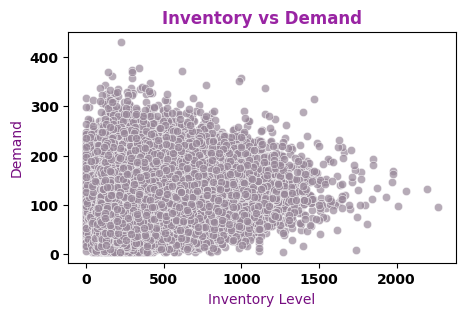

In [25]:
plt.figure(figsize=(5,3))

sns.scatterplot(
    x="Inventory Level",
    y="Demand",
    data=df,
    color="#988899",
    alpha=0.7
)

plt.title("Inventory vs Demand", color="#9924A3", fontweight="bold")

plt.xlabel("Inventory Level", color="#760D80")
plt.ylabel("Demand", color="#760D80")

plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.show()


In [26]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, rf_pred))

Random Forest R2: 0.8507206333746381


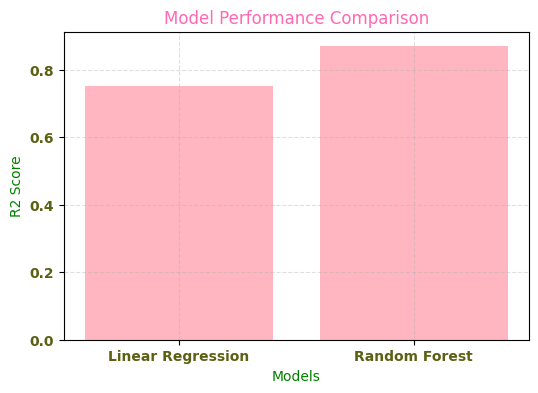

In [27]:
models = ["Linear Regression", "Random Forest"]
scores = [0.752, 0.869]

plt.figure(figsize=(6,4))


plt.bar(models, scores, color="lightpink")

plt.title("Model Performance Comparison", color="hotpink")

# Axis labels in green
plt.xlabel("Models", color="green")
plt.ylabel("R2 Score", color="green")
plt.grid(True, linestyle='--', alpha=0.4)
plt.yticks(fontweight="bold",color="#5C6013")
plt.xticks(fontweight="bold",color="#5C6013")

plt.show()

In [28]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Decision Tree R2:",r2_score(y_test, y_pred_dt))
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))

Decision Tree R2: 0.7051232265060632
Decision Tree RMSE: 25.519404381764087


In [29]:
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1)

gb.fit(X_train, y_train)
7
y_pred_gb = gb.predict(X_test)

print("Gradient Boosting R2:", r2_score(y_test, y_pred_gb))
print("Gradient Boosting RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))


Gradient Boosting R2: 0.6502468378027422
Gradient Boosting RMSE: 27.792721511583345


In [30]:
xgb = XGBRegressor()

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

R2 Score: 0.8634817004203796
RMSE: 17.36383707982673


In [31]:

data = {
    "Model": ["DecisionTreeRegressor", 
              "GradientBoostingRegressor", 
              "XGBRegressor"],
    "R2 Score": [0.75, 0.85, 0.90]
}

results = pd.DataFrame(data)

print(results.sort_values(by="R2 Score", ascending=False))

                       Model  R2 Score
2               XGBRegressor      0.90
1  GradientBoostingRegressor      0.85
0      DecisionTreeRegressor      0.75


               Feature  Importance
12            Epidemic    0.230432
9            Promotion    0.225209
5        Units Ordered    0.191824
2             Category    0.112479
8    Weather Condition    0.050458
6                Price    0.028203
11         Seasonality    0.027385
1           Product ID    0.023782
3               Region    0.023578
4      Inventory Level    0.022144
0             Store ID    0.020079
14               Month    0.017262
10  Competitor Pricing    0.012088
7             Discount    0.009920
13                Year    0.002646
15                 Day    0.002510


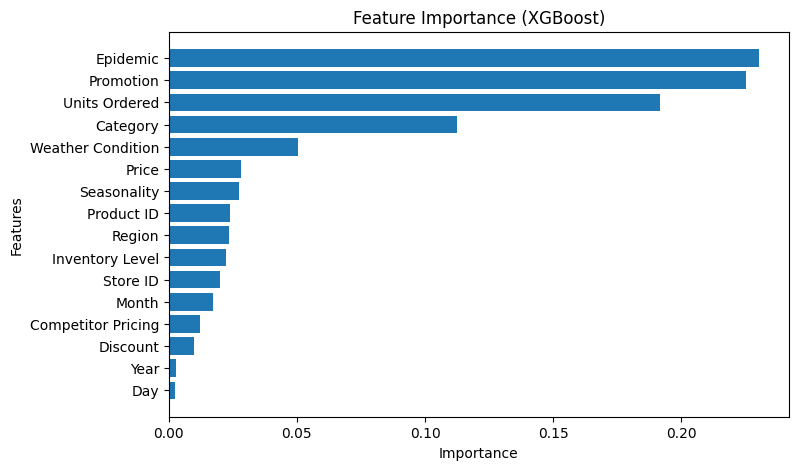

In [32]:

importance = xgb.feature_importances_

features = X.columns

feature_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

feature_imp = feature_imp.sort_values(by="Importance", ascending=False)


print(feature_imp)

plt.figure(figsize=(8,5))
plt.barh(feature_imp["Feature"], feature_imp["Importance"])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance (XGBoost)")
plt.gca().invert_yaxis()   
plt.show()

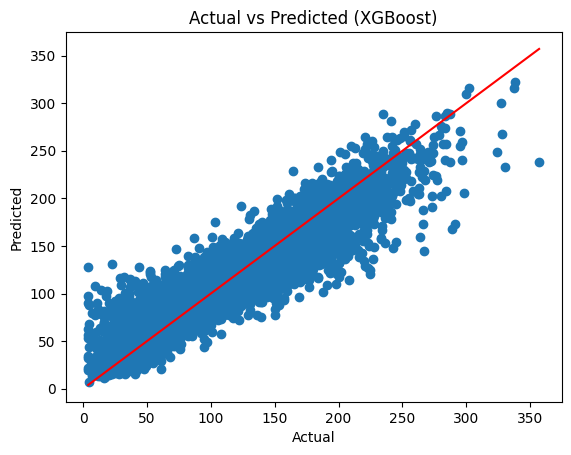

In [ ]:


plt.scatter(y_test, y_pred_xgb)

# Perfect line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (XGBoost)")
plt.show()